Shape: (718, 12)

Columns:
['id', 'word', 'reading', 'level', 'type', 'subtype', 'primary_meanings', 'sentence_ja', 'sentence_en', 'kanji_frequency_difficulty', 'kanji_usage_difficulty', 'kanji_in_n5_list']

Data types:
id                              int64
word                           object
reading                        object
level                          object
type                           object
subtype                        object
primary_meanings               object
sentence_ja                    object
sentence_en                    object
kanji_frequency_difficulty    float64
kanji_usage_difficulty        float64
kanji_in_n5_list                 bool
dtype: object

First 5 rows:


,id,word,reading,level,type,subtype,primary_meanings,sentence_ja,sentence_en,kanji_frequency_difficulty,kanji_usage_difficulty,kanji_in_n5_list
0,1,嗚呼,ああ,N5,word,NaN,ah!; oh!; alas!,ああ、なるほど！,"Ah, gotcha!",9.0,9.0,False
1,2,会う,あう,N5,word,NaN,to meet; to encounter; to see,前に彼にあったのを覚えている。,I remember seeing him before.,2.0,3.0,False
2,3,青,あお,N5,word,NaN,blue; azure; green,信号が青に変わったわよ。,The traffic light turned green.,7.0,6.0,False
3,4,青い,あおい,N5,word,NaN,blue; azure; green,お前はまだ「青い」な。,You're still green.,7.0,6.0,False
4,5,赤,あか,N5,word,NaN,red; crimson; scarlet,信号機が赤の間は道路を渡るな。,Don't cross the road when the signal is red.,7.0,5.0,False



Missing values per column:
subtype                       677
kanji_frequency_difficulty    111
kanji_usage_difficulty        111
sentence_ja                    42
sentence_en                    42
id                              0
word                            0
reading                         0
level                           0
type                            0
primary_meanings                0
kanji_in_n5_list                0
dtype: int64

Duplicate rows: 0

Numeric summary:


,id,kanji_frequency_difficulty,kanji_usage_difficulty
count,718.000000,607.000000,607.000000
mean,359.500000,6.537068,6.200988
std,207.413034,2.487897,1.746037
min,1.000000,2.000000,2.000000
25%,180.250000,4.000000,5.000000
50%,359.500000,7.000000,6.000000
75%,538.750000,9.000000,8.000000
max,718.000000,10.000000,10.000000



Categorical/text summary:


,word,reading,level,type,subtype,primary_meanings,sentence_ja,sentence_en
count,718,718,718,718,41,718,676,676
unique,695,689,1,2,5,694,645,644
top,九,あつい,N5,word,counter,nine; 9,あの〜郵便局はどちらでしょうか。,"Uh..., where's the post office?"
freq,3,3,718,677,14,3,3,3


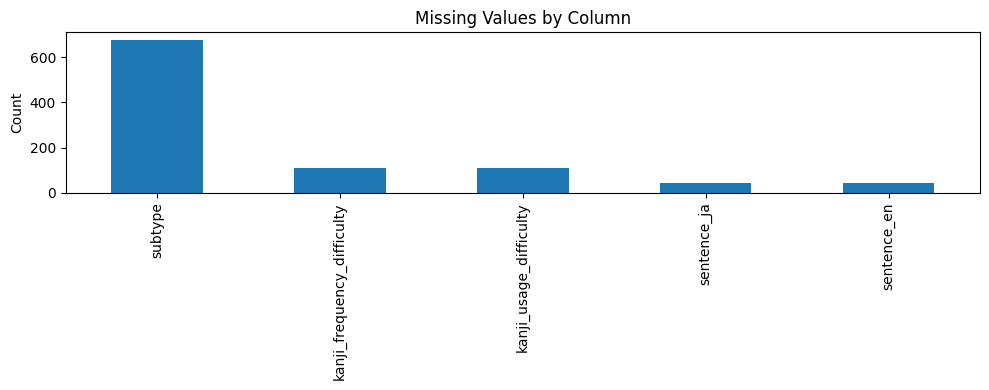

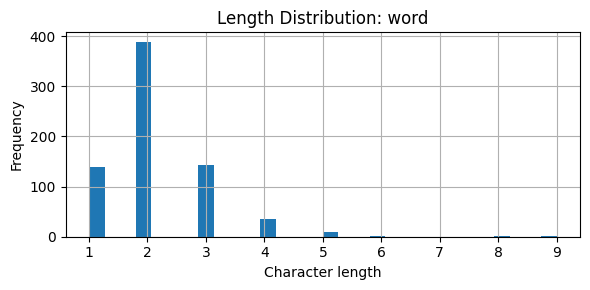

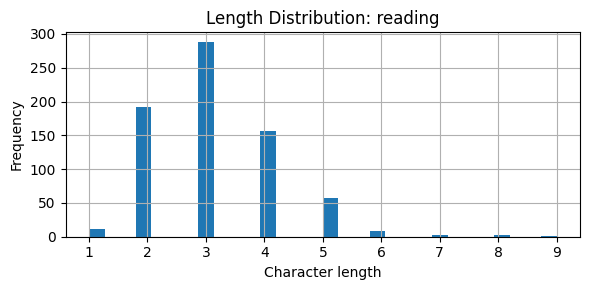

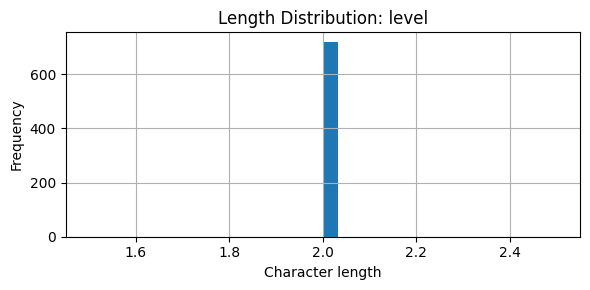

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load and do basic EDA for the `n5_vocabulary` dataset

# 1) Load dataset (Hugging Face Datasets)
df = pd.read_csv("n5_vocabulary.csv")

# 2) Convert to a single pandas DataFrame
# if hasattr(ds, "keys"):  # DatasetDict with splits
#     frames = []
#     for split_name in ds.keys():
#         temp = ds[split_name].to_pandas()
#         temp["split"] = split_name
#         frames.append(temp)
#     df = pd.concat(frames, ignore_index=True)
# else:
#     df = ds.to_pandas()

# 3) Basic overview
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

# 4) Data quality checks
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

# 5) Quick stats
print("\nNumeric summary:")
display(df.describe(include="number"))

print("\nCategorical/text summary:")
display(df.describe(include=["object", "string", "category"]))

# 6) Optional simple visual EDA
# Missing values bar chart
missing = df.isna().sum()
if missing.sum() > 0:
    plt.figure(figsize=(10, 4))
    missing[missing > 0].sort_values(ascending=False).plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Distribution of text length for likely text columns
text_cols = [c for c in df.columns if str(df[c].dtype) in ("object", "string")]
for c in text_cols[:3]:  # limit to first 3 text columns
    lengths = df[c].astype(str).str.len()
    plt.figure(figsize=(6, 3))
    lengths.hist(bins=30)
    plt.title(f"Length Distribution: {c}")
    plt.xlabel("Character length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()